<a href="https://colab.research.google.com/github/HuanNguyen213421345/thuvien/blob/main/_notebooks/2020-10-24-Support%20Vector%20Regression%20(SVR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Regression (SVR)

> A tutorial on How to use SVR.

- toc: true
- badges: true
- comments: true
- categories: [jupyter, Regression]

## 0. Data Preprocessing

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train_Bearing1_5_fixed_band_ver2.zip to train_Bearing1_5_fixed_band_ver2.zip


In [2]:
import zipfile

with zipfile.ZipFile("train_Bearing1_5_fixed_band_ver2.zip", 'r') as zip_ref:
    zip_ref.extractall("train_Bearing1_5_fixed_band_ver2")


In [3]:
import os

os.listdir("train_Bearing1_5_fixed_band_ver2")

['train_Bearing1_1_fixed_band.csv',
 'train_Bearing1_5_fixed_band.csv',
 'train_Bearing1_4_fixed_band.csv',
 'train_Bearing1_3_fixed_band.csv',
 'train_Bearing1_2_fixed_band.csv']

### 0.1 Importing the libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

### 0.2 Importing the dataset

In [5]:
train1 = pd.read_csv("train_Bearing1_5_fixed_band_ver2/train_Bearing1_1_fixed_band.csv")

train2 = pd.read_csv("train_Bearing1_5_fixed_band_ver2/train_Bearing1_2_fixed_band.csv")

train3 = pd.read_csv("train_Bearing1_5_fixed_band_ver2/train_Bearing1_3_fixed_band.csv")

train4 = pd.read_csv("train_Bearing1_5_fixed_band_ver2/train_Bearing1_4_fixed_band.csv")

test = pd.read_csv("train_Bearing1_5_fixed_band_ver2/train_Bearing1_5_fixed_band.csv")

In [6]:
train_df = pd.concat(

    [train1, train2, train3, train4],

    ignore_index=True
)

### 0.3 Split into X & y

In [7]:
X_train = train_df.drop(columns=["RUL"]).values

y_train = train_df["RUL"].values


X_test = test.drop(columns=["RUL"]).values

y_test = test["RUL"].values

### 0.4 Feature Scaling

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(

    n_components=0.95
)

In [10]:
X_train_pca = pca.fit_transform(

    X_train_scaled
)

X_test_pca = pca.transform(

    X_test_scaled
)

In [11]:
print(

    "Original:",

    X_train.shape[1]
)

print(

    "After PCA:",

    X_train_pca.shape[1]
)

Original: 11
After PCA: 5


## 1. Training the model on the whole dataset

In [12]:
from sklearn.svm import SVR

model = SVR(

    kernel='rbf',

    C=10,

    gamma='scale',

    epsilon=0.01
)

model.fit(

    X_train_pca,

    y_train
)

SVR(C=10, epsilon=0.01)

## 2. Predicting a new result with SVR

In [13]:
y_pred = model.predict(

    X_test_pca
)

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)

print("MAE:", mae)

print("R2:", r2)

RMSE: 0.2501350962123037
MAE: 0.2106947221098029
R2: 0.2775216865930431


## 3. Visualising the SVR results

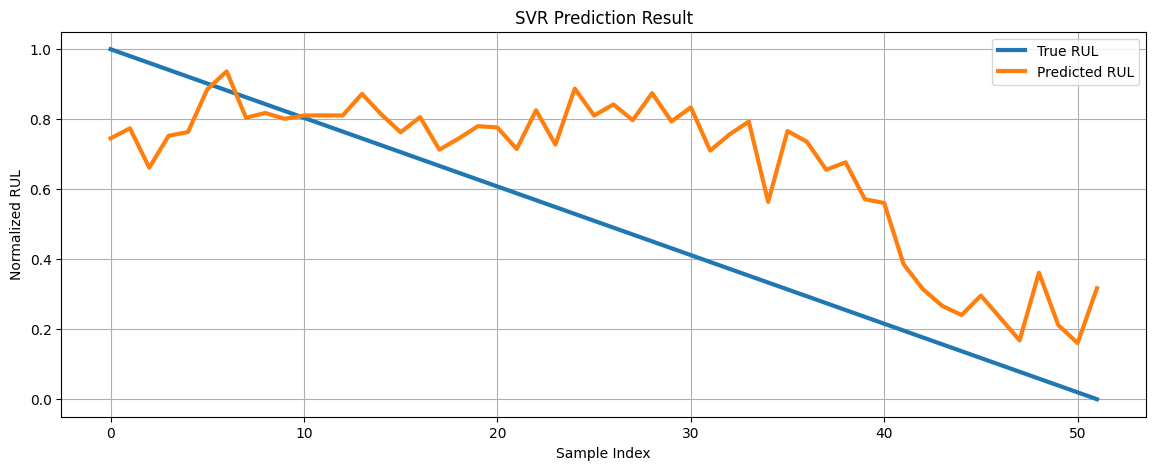

In [15]:
# =====================================================
# SHOW SVR PREDICTION RESULT
# =====================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# TRUE RUL
plt.plot(

    y_test,

    label="True RUL",

    linewidth=3
)

# PREDICTED RUL
plt.plot(

    y_pred,

    label="Predicted RUL",

    linewidth=3
)

plt.xlabel("Sample Index")

plt.ylabel("Normalized RUL")

plt.title("SVR Prediction Result")

plt.legend()

plt.grid(True)

plt.show()